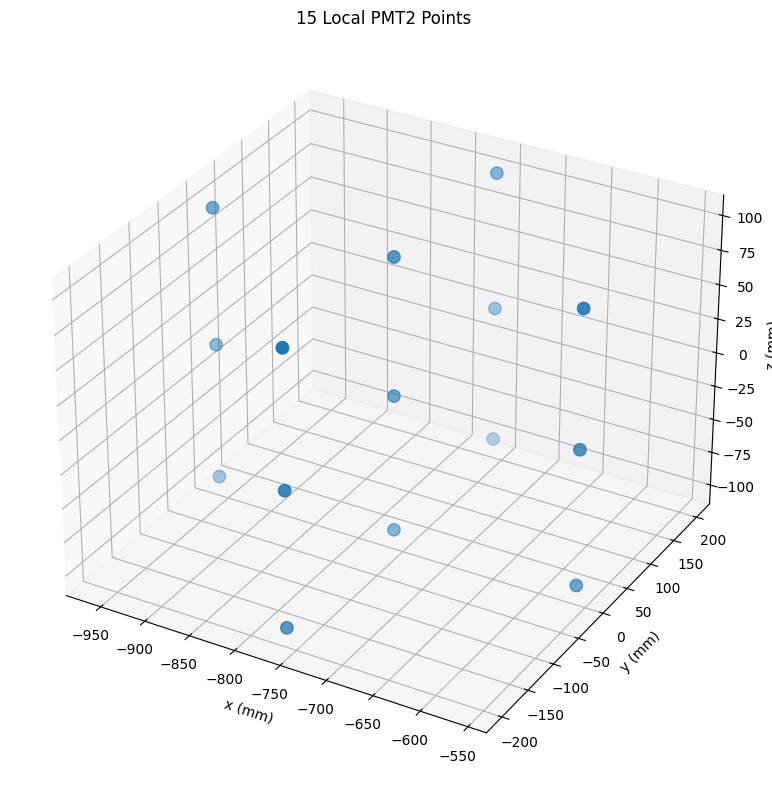

Computing column for X1 ...
Computing column for X2 ...
Computing column for X3 ...
Computing column for Y1 ...
Computing column for Y2 ...
Computing column for Z1 ...
Computing column for Z2 ...

LOCAL MATRICES
Ax_local shape = (15, 7)
Ay_local shape = (15, 7)
Az_local shape = (15, 7)
A_local shape  = (45, 7)

A_red_local shape = (45, 5)

Bx TARGET = -300 mG

Optimized currents:
X1 = 3.122 A
X2 = 54.336 A
X3 = -323.311 A
Y  = -21.568 A
Z  = 72.193 A

Actual Bx at 15 points:
[-298.614 -300.19  -304.376 -299.265 -293.923 -299.828 -302.797 -302.432
 -300.495 -295.069 -300.767 -303.909 -300.677 -301.444 -295.974]

Mean = -299.984 mG
RMS  = 2.961 mG

Bx TARGET = -250 mG

Optimized currents:
X1 = 12.873 A
X2 = 62.859 A
X3 = -322.116 A
Y  = -21.550 A
Z  = 72.192 A

Actual Bx at 15 points:
[-248.952 -249.861 -254.092 -249.619 -244.225 -249.978 -252.365 -251.968
 -250.66  -245.183 -251.053 -253.552 -250.342 -251.746 -246.224]

Mean = -249.988 mG
RMS  = 2.776 mG

Bx TARGET = -200 mG

Optimized 

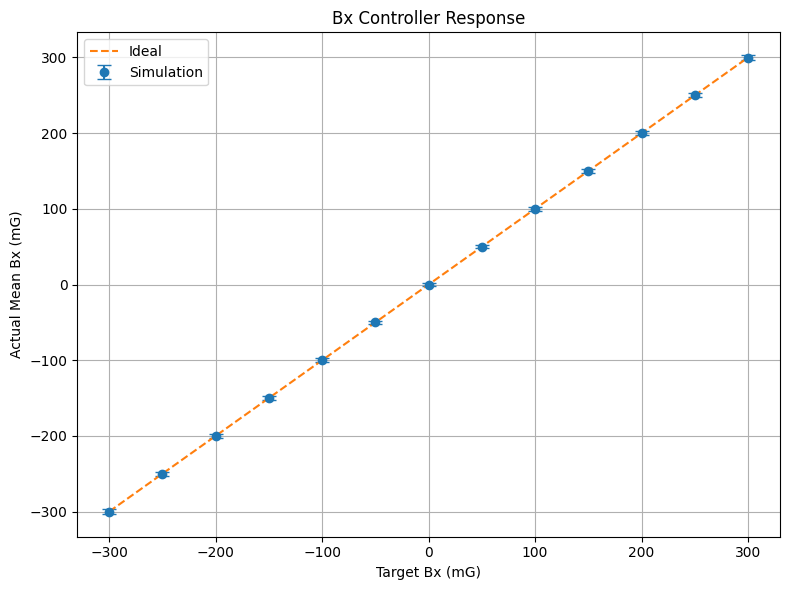

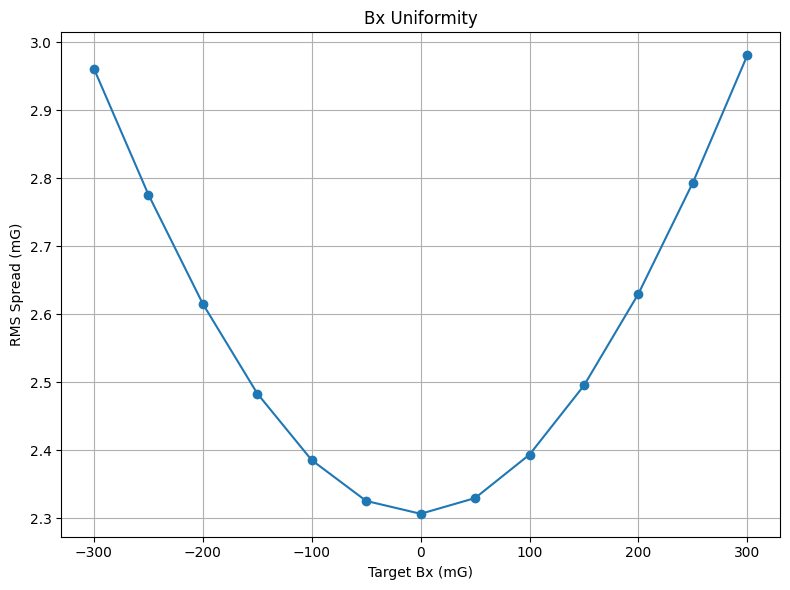


By TARGET = -300 mG

Optimized currents:
X1 = 79.526 A
X2 = 266.607 A
X3 = -1226.175 A
Y  = -82.025 A
Z  = 72.229 A

Actual By at 15 points:
[-296.957 -308.461 -285.052 -309.407 -292.528 -298.749 -310.329 -286.761
 -309.026 -295.627 -298.608 -310.181 -286.622 -309.08  -295.671]

Mean = -299.537 mG
RMS  = 9.001 mG

By TARGET = -250 mG

Optimized currents:
X1 = 76.543 A
X2 = 239.751 A
X3 = -1074.502 A
Y  = -71.931 A
Z  = 72.222 A

Actual By at 15 points:
[-247.253 -257.371 -236.791 -258.195 -243.357 -248.907 -259.095 -238.369
 -257.844 -246.238 -248.866 -259.051 -238.325 -257.876 -246.439]

Mean = -249.599 mG
RMS  = 7.892 mG

By TARGET = -200 mG

Optimized currents:
X1 = 73.560 A
X2 = 212.896 A
X3 = -922.830 A
Y  = -61.837 A
Z  = 72.216 A

Actual By at 15 points:
[-197.549 -206.281 -188.531 -206.982 -194.186 -199.066 -207.861 -189.977
 -206.663 -196.85  -199.124 -207.921 -190.027 -206.672 -197.207]

Mean = -199.660 mG
RMS  = 6.785 mG

By TARGET = -150 mG

Optimized currents:
X1 = 70.578

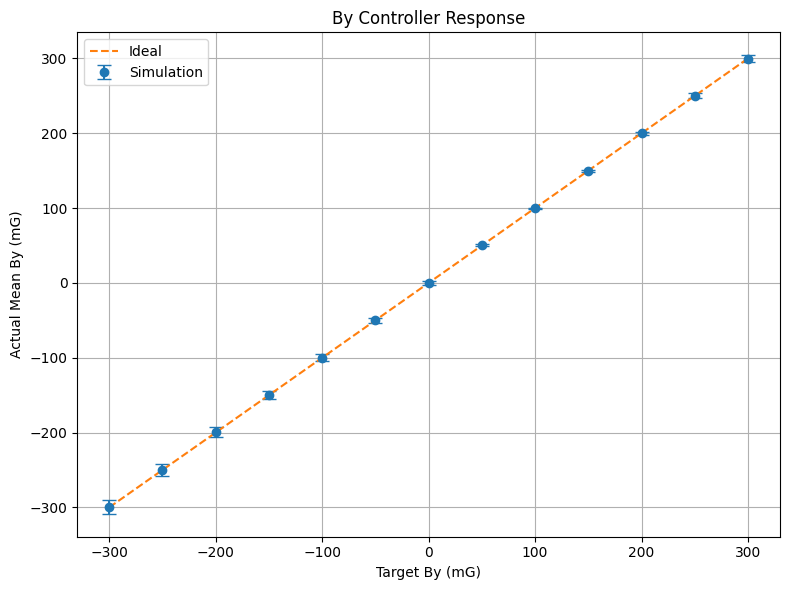

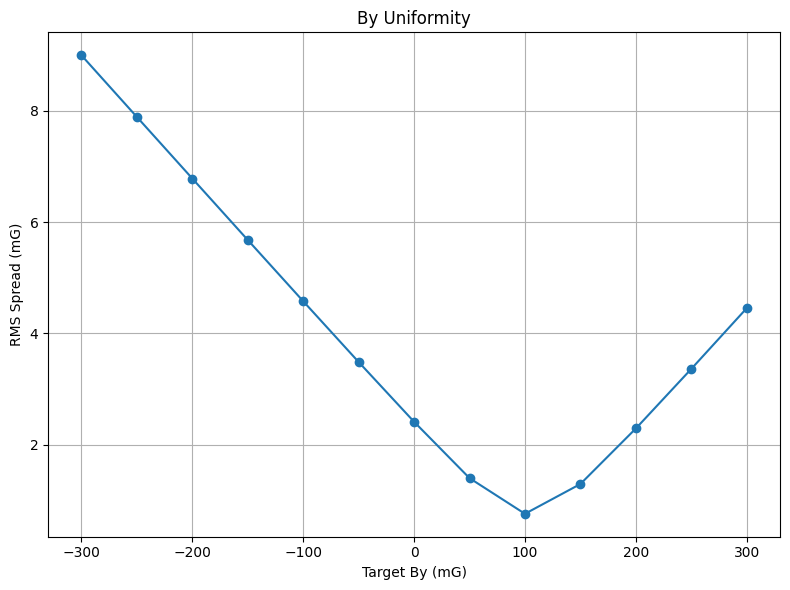


Bz TARGET = -300 mG

Optimized currents:
X1 = 61.635 A
X2 = 105.623 A
X3 = -316.948 A
Y  = -21.459 A
Z  = 15.386 A

Actual Bz at 15 points:
[-300.326 -299.243 -304.65  -300.953 -298.4   -299.946 -300.449 -300.371
 -300.097 -299.409 -299.452 -301.629 -295.702 -299.146 -300.266]

Mean = -300.002 mG
RMS  = 1.802 mG

Bz TARGET = -250 mG

Optimized currents:
X1 = 61.634 A
X2 = 105.598 A
X3 = -316.813 A
Y  = -21.460 A
Z  = 24.853 A

Actual Bz at 15 points:
[-250.277 -249.625 -254.566 -250.977 -248.078 -249.921 -250.806 -250.416
 -250.143 -249.121 -249.4   -252.009 -245.615 -249.167 -249.941]

Mean = -250.004 mG
RMS  = 1.856 mG

Bz TARGET = -200 mG

Optimized currents:
X1 = 61.633 A
X2 = 105.573 A
X3 = -316.678 A
Y  = -21.460 A
Z  = 34.320 A

Actual Bz at 15 points:
[-200.228 -200.007 -204.482 -201.001 -197.756 -199.897 -201.163 -200.46
 -200.19  -198.832 -199.348 -202.389 -195.528 -199.188 -199.616]

Mean = -200.006 mG
RMS  = 1.934 mG

Bz TARGET = -150 mG

Optimized currents:
X1 = 61.632 A


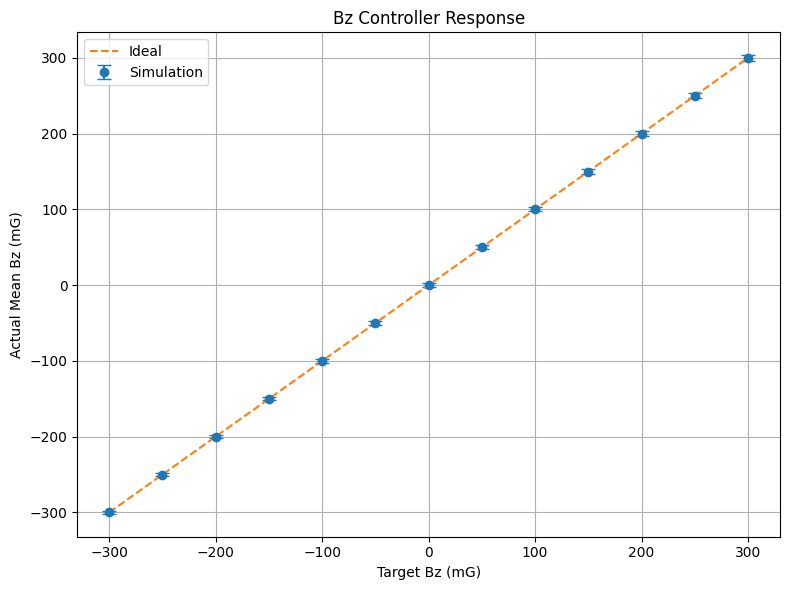

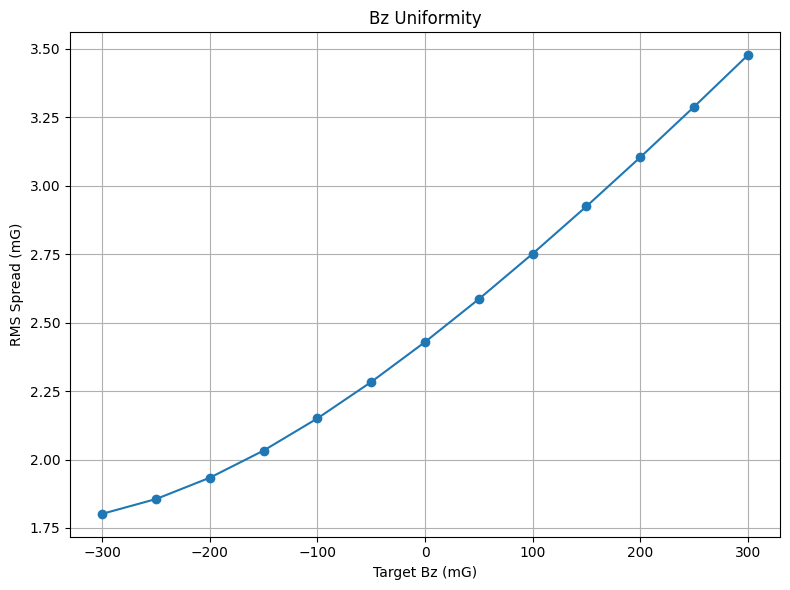

In [2]:
# ============================================================
# NOTEBOOK 11
#
# 15-POINT PMT2 LOCAL FIELD CONTROLLER ANALYSIS
#
# Performs:
#
# 1. Build 15 local PMT points
# 2. Construct local transfer matrices
# 3. Build grouped matrix
# 4. Perform:
#       Bx scan
#       By scan
#       Bz scan
#
# 5. Plot:
#       Target vs Actual
#       RMS spread vs Target
#
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import sys
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# ADD PROJECT ROOT
# ============================================================

project_root = Path.cwd().parent

sys.path.append(str(project_root))

# ============================================================
# IMPORT YOUR MODULES
# ============================================================

from src.coils import coils
from src.field_solver import total_field_at_point

# ============================================================
# PMT2 CENTER
# ============================================================

xc = -760e-3
yc = 0e-3
zc = 0e-3

# ============================================================
# BUILD 15 LOCAL POINTS
#
# 3 z-planes:
#
# z = -100 mm
# z =   0 mm
# z = +100 mm
#
# each plane:
#
# center
# ±x
# ±y
#
# ============================================================

offset = 200e-3

z_planes = [

    -100e-3,
     0e-3,
     100e-3
]

local_points = []

for dz in z_planes:

    z = zc + dz

    plane_points = [

        [xc, yc, z],

        [xc + offset, yc, z],
        [xc - offset, yc, z],

        [xc, yc + offset, z],
        [xc, yc - offset, z]
    ]

    local_points.extend(plane_points)

local_points = np.array(local_points)

# ============================================================
# PLOT 15 POINTS
# ============================================================

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(

    local_points[:,0] * 1000,
    local_points[:,1] * 1000,
    local_points[:,2] * 1000,

    s=80
)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')

ax.set_title('15 Local PMT2 Points')

plt.tight_layout()
plt.show()

# ============================================================
# COIL NAMES
# ============================================================

coil_names = [

    'X1',
    'X2',
    'X3',

    'Y1',
    'Y2',

    'Z1',
    'Z2'
]

# ============================================================
# INITIALIZE MATRICES
# ============================================================

n_points = len(local_points)

n_coils = len(coil_names)

Ax_local = np.zeros((n_points, n_coils))

Ay_local = np.zeros((n_points, n_coils))

Az_local = np.zeros((n_points, n_coils))

# ============================================================
# UNIT CONVERSION
# Tesla -> mG
# ============================================================

mG_conversion = 1e7

# ============================================================
# BUILD LOCAL MATRICES
# ============================================================

for j, coil_name in enumerate(coil_names):

    print(f'Computing column for {coil_name} ...')

    # --------------------------------------------------------
    # UNIT CURRENT CONFIGURATION
    # --------------------------------------------------------

    currents = {

        name: 0.0
        for name in coil_names
    }

    currents[coil_name] = 1.0

    # --------------------------------------------------------
    # LOOP OVER POINTS
    # --------------------------------------------------------

    for i, point in enumerate(local_points):

        B = total_field_at_point(

            point,
            coils,
            currents
        )

        B *= mG_conversion

        Ax_local[i,j] = B[0]

        Ay_local[i,j] = B[1]

        Az_local[i,j] = B[2]

# ============================================================
# BUILD FULL MATRIX
# ============================================================

A_local = np.vstack([

    Ax_local,
    Ay_local,
    Az_local
])

print("\n================================================")
print("LOCAL MATRICES")
print("================================================")

print("Ax_local shape =", Ax_local.shape)
print("Ay_local shape =", Ay_local.shape)
print("Az_local shape =", Az_local.shape)
print("A_local shape  =", A_local.shape)

# ============================================================
# GROUP Y AND Z COILS
#
# X coils independent
# Y grouped
# Z grouped
#
# FINAL:
#
# [X1 X2 X3 Y Z]
#
# shape = (45,5)
#
# ============================================================

A_red_local = np.column_stack([

    A_local[:,0],                  # X1
    A_local[:,1],                  # X2
    A_local[:,2],                  # X3

    A_local[:,3] + A_local[:,4],  # Y

    A_local[:,5] + A_local[:,6]   # Z
])

print("\nA_red_local shape =", A_red_local.shape)

# ============================================================
# AMBIENT FIELD
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# FUNCTION:
# RUN COMPONENT SCAN
# ============================================================

def run_scan(

    component='Bx',
    targets=np.arange(-300, 301, 50)
):

    # --------------------------------------------------------
    # DIRECTION VECTOR
    # --------------------------------------------------------

    if component == 'Bx':

        direction = np.array([1,0,0])

    elif component == 'By':

        direction = np.array([0,1,0])

    elif component == 'Bz':

        direction = np.array([0,0,1])

    else:

        raise ValueError("Invalid component")

    # ========================================================
    # STORAGE
    # ========================================================

    actual_means = []

    actual_rms = []

    all_currents = []

    # ========================================================
    # MAIN LOOP
    # ========================================================

    for target in targets:

        print("\n================================================")
        print(f"{component} TARGET = {target} mG")
        print("================================================")

        # ----------------------------------------------------
        # USER DESIRED FIELD
        # ----------------------------------------------------

        B_in = target * direction

        # ----------------------------------------------------
        # FIELD COILS MUST GENERATE
        # ----------------------------------------------------

        target_single = B_in - B_ambient

        # ----------------------------------------------------
        # BUILD TARGET VECTOR
        # ----------------------------------------------------

        Bx_vec = np.full(

            n_points,
            target_single[0]
        )

        By_vec = np.full(

            n_points,
            target_single[1]
        )

        Bz_vec = np.full(

            n_points,
            target_single[2]
        )

        B_target = np.concatenate([

            Bx_vec,
            By_vec,
            Bz_vec
        ])

        # ====================================================
        # OPTIMIZATION
        # ====================================================

        I_opt, residuals, rank, s = np.linalg.lstsq(

            A_red_local,
            B_target,
            rcond=None
        )

        all_currents.append(I_opt)

        # ====================================================
        # COMPUTE ACTUAL FIELD
        # ====================================================

        B_coil = A_red_local @ I_opt

        B_ambient_vec = np.concatenate([

            np.full(n_points, B_ambient[0]),

            np.full(n_points, B_ambient[1]),

            np.full(n_points, B_ambient[2])
        ])

        B_actual = B_coil + B_ambient_vec

        # ====================================================
        # EXTRACT COMPONENT
        # ====================================================

        if component == 'Bx':

            B_component = B_actual[:n_points]

        elif component == 'By':

            B_component = B_actual[n_points:2*n_points]

        else:

            B_component = B_actual[2*n_points:]

        # ====================================================
        # STATISTICS
        # ====================================================

        mean_val = np.mean(B_component)

        rms_val = np.std(B_component)

        actual_means.append(mean_val)

        actual_rms.append(rms_val)

        # ====================================================
        # PRINT RESULTS
        # ====================================================

        print("\nOptimized currents:")

        print(f"X1 = {I_opt[0]:.3f} A")
        print(f"X2 = {I_opt[1]:.3f} A")
        print(f"X3 = {I_opt[2]:.3f} A")

        print(f"Y  = {I_opt[3]:.3f} A")
        print(f"Z  = {I_opt[4]:.3f} A")

        print(f"\nActual {component} at 15 points:")

        print(np.round(B_component, 3))

        print(f"\nMean = {mean_val:.3f} mG")

        print(f"RMS  = {rms_val:.3f} mG")

    # ========================================================
    # CONVERT TO ARRAYS
    # ========================================================

    actual_means = np.array(actual_means)

    actual_rms = np.array(actual_rms)

    # ========================================================
    # PLOT:
    # TARGET vs ACTUAL
    # ========================================================

    plt.figure(figsize=(8,6))

    plt.errorbar(

        targets,

        actual_means,

        yerr=actual_rms,

        fmt='o',

        capsize=5,

        label='Simulation'
    )

    # --------------------------------------------------------
    # IDEAL LINE
    # --------------------------------------------------------

    plt.plot(

        targets,

        targets,

        '--',

        label='Ideal'
    )

    plt.xlabel(f'Target {component} (mG)')

    plt.ylabel(f'Actual Mean {component} (mG)')

    plt.title(f'{component} Controller Response')

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()

    # ========================================================
    # RMS PLOT
    # ========================================================

    plt.figure(figsize=(8,6))

    plt.plot(

        targets,

        actual_rms,

        'o-'
    )

    plt.xlabel(f'Target {component} (mG)')

    plt.ylabel('RMS Spread (mG)')

    plt.title(f'{component} Uniformity')

    plt.grid(True)

    plt.tight_layout()

    plt.show()

    return {

        'targets': targets,

        'means': actual_means,

        'rms': actual_rms,

        'currents': all_currents
    }

# ============================================================
# RUN SCANS
# ============================================================

results_Bx = run_scan('Bx')

results_By = run_scan('By')

results_Bz = run_scan('Bz')

In [4]:
# ------------------------------------------------------------
# Bz scan currents
# ------------------------------------------------------------

plt.figure(figsize=(9,6))

for i in range(5):

    plt.plot(

        targets,

        results_Bz['currents'][:,i],

        marker='o',

        label=coil_labels[i]
    )

plt.xlabel('Bz Target (mG)')

plt.ylabel('Current (A)')

plt.title('Optimized Currents During Bz Scan')

plt.grid(True)

plt.legend()

plt.show()

NameError: name 'targets' is not defined

<Figure size 900x600 with 0 Axes>